<a href="https://colab.research.google.com/github/emzu/futureIDF/blob/main/02)Viz_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Initialization

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git config --global user.email "ezuetell@andrew.cmu.edu"
!git config --global user.name "emzu"

try:
    !git clone "https://github.com/emzu/futureIDF"
except:
    print("Already cloned")

%cd /content/futureIDF
!git pull

# Load Packages
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'futureIDF'...
remote: Enumerating objects: 72, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 72 (delta 29), reused 41 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (72/72), 10.56 MiB | 15.40 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/futureIDF
Already up to date.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.

In [2]:
!git pull

# Import modules
import sys
import importlib
# Ensure workspace root is on sys.path so the local `modules` package can be imported
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
import warnings
warnings.filterwarnings('ignore')

from modules import config, data_io, timeseries, plotting, process_rp, geospatial
importlib.reload(timeseries)
importlib.reload(data_io)
importlib.reload(process_rp)
importlib.reload(geospatial)

Already up to date.


<module 'modules.geospatial' from '/content/futureIDF/modules/geospatial.py'>

# Gridded Precip Data

In [14]:
DIRECTORY = "/content/drive/MyDrive/Research/MARISA_IDF/data/LOCA2/MARISA/"
model = config.MODELS_LOCA2[0]
result = xr.open_dataset(f'{DIRECTORY}/{model}.historical.{str(1950)}-{str(2000)}_processed.zarr', zarr_format=2, consolidated=False)

Annual Maximum Series (AMS):
  Shape: (51, 103, 144)
  Years: 51
  Range: 0.57 to 19.76 inches/day

Annual Totals:
  Shape: (51, 103, 144)
  Range: 0.00 to 79.13 inches/year


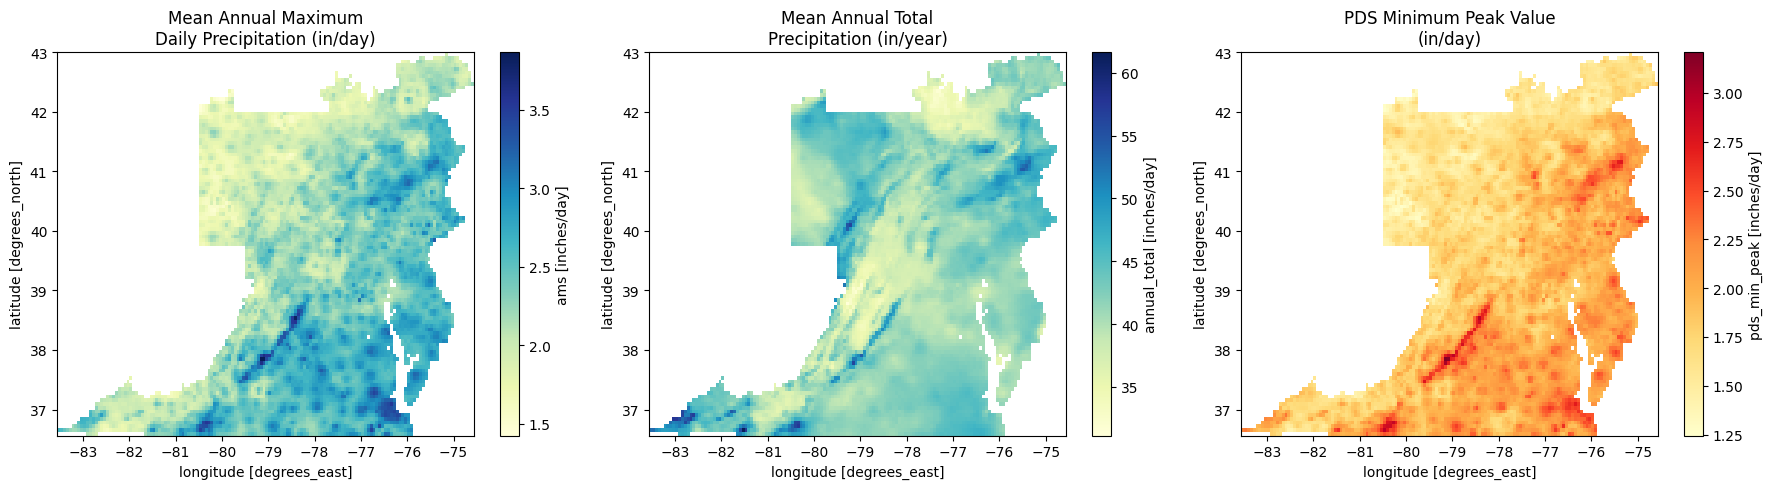

In [15]:
if 'ensemble' in result.dims:
    result = result.sel(ensemble = 1)

# Annual Maximum Series (AMS)
ams = result['ams']
print("Annual Maximum Series (AMS):")
print(f"  Shape: {ams.shape}")
print(f"  Years: {len(ams.year)}")
print(f"  Range: {ams.min().values:.2f} to {ams.max().values:.2f} inches/day")

# Annual Totals
annual_totals = result['annual_total']
print("\nAnnual Totals:")
print(f"  Shape: {annual_totals.shape}")
print(f"  Range: {annual_totals.min().values:.2f} to {annual_totals.max().values:.2f} inches/year")

# PDS (if computed)
if 'pds_n_peaks' in result:
    n_peaks = result['pds_n_peaks']
    threshold = result['pds_threshold']
    print("\nPartial Duration Series (PDS):")
    print(f"  Mean peaks per grid cell: {n_peaks.mean().values:.1f}")
    print(f"  Threshold range: {threshold.min().values:.2f} to {threshold.max().values:.2f} inches/day")

# Plot mean AMS across all years
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mean AMS
ams.mean(dim='year').plot(ax=axes[0], cmap='YlGnBu')
axes[0].set_title('Mean Annual Maximum\nDaily Precipitation (in/day)')

# Mean Annual Total
mean_annual_totals = annual_totals.mean(dim='year')
mean_annual_totals = mean_annual_totals.where(mean_annual_totals != 0)
mean_annual_totals.plot(ax=axes[1], cmap='YlGnBu')
axes[1].set_title('Mean Annual Total\nPrecipitation (in/year)')

# PDS threshold (if available)
if 'pds_min_peak' in result:
    result['pds_min_peak'].plot(ax=axes[2], cmap='YlOrRd')
    axes[2].set_title('PDS Minimum Peak Value\n(in/day)')
else:
    # Plot number of peaks instead
    axes[2].text(0.5, 0.5, 'PDS not computed', ha='center', va='center')
    axes[2].axis('off')

plt.tight_layout()
plt.show()

# County-Level Adjustment Factors

In [3]:
LOCA = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED/adj_factors_combined_LOCA_lmom_smoothedcentroid_nb100_1950_2000.zarr", consolidated = False)
LOCA2 = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED/adj_factors_combined_LOCA2_lmom_smoothedcentroid_nb100_1950_2000.zarr", consolidated = False)

<Axes: >

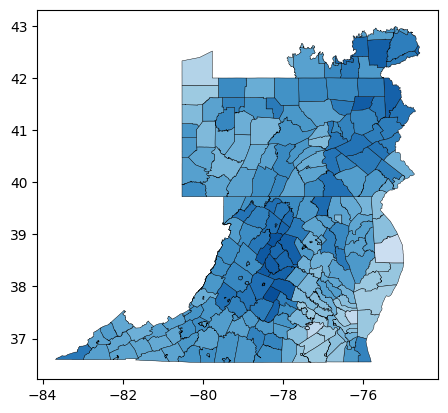

In [16]:

gdf = geospatial.merged_xarr_county(
            LOCA2['adj_factor']
              .sel(return_periods=25, scenario='ssp245', time_period='2050-2100')
              .mean(dim='centroid_cell')
              .median(dim=['model', 'n_b']),
            interpolate=True
        )
gdf.plot(column='adj_factor', cmap='Blues', legend=False,
          edgecolor='black', linewidth=0.3,
          vmin=1, vmax=1.3)